In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

Task 1: Simulate Dataset

In [10]:
num_threads = 250

data = {
    'thread_id': np.arange(1, num_threads+1),
    'likes': np.random.randint(0, 101, size = num_threads),
    'replies': np.random.randint(0, 51, size = num_threads),
    'reposts': np.random.randint(0, 31, size = num_threads),
    'age_minutes': np.random.randint(0, 361, size = num_threads)
}

threads_df = pd.DataFrame(data)

threads_df.to_csv('threads.csv', index=False)

Task 2: Vectorized Scoring Function

In [ ]:
#Calculate the score for each thread using vectorized function
threads_df['scores'] = (threads_df['likes']*2) + (threads_df['replies']*3) + (threads_df['reposts']*2.5) * np.exp(-threads_df['age_minutes']/120)

print(threads_df)

     thread_id  likes  replies  reposts  age_minutes      scores
0            1     17       46       26          134  193.278999
1            2     83        2        5          265  173.373545
2            3     51       49       12          138  258.499103
3            4     53       10        8          357  137.020949
4            5     12       42       15           75  170.072304
..         ...    ...      ...      ...          ...         ...
245        246     68       31       12          202  234.572613
246        247     77        5       20           64  198.332311
247        248     13       11       17          256   64.033778
248        249     95       48       16           42  362.187524
249        250     84       23       22            8  288.452884

[250 rows x 6 columns]


Task 3: Feed Ranking and Export

In [ ]:
#create a new dataframe sort by score in descending order
threads_df_desc = threads_df.sort_values(by = 'scores', ascending=False)
print(threads_df_desc)


top_10_threads = threads_df_desc.head(10) #extract the top10 results
top_10_threads.to_csv('top_threads.csv', index=False)

     thread_id  likes  replies  reposts  age_minutes      scores
153        154     93       48       29           69  370.796103
157        158     91       48       18            6  368.805324
248        249     95       48       16           42  362.187524
129        130     98       47       13           97  351.482004
14          15     89       48       26          117  346.517503
..         ...    ...      ...      ...          ...         ...
108        109     24        0       18          182   57.874896
235        236     19        5       10          249   56.138911
238        239      2       13        3           51   47.903273
121        122     17        2       26          339   43.855063
130        131      3        0        2          221    6.792765

[250 rows x 6 columns]


The scores evaluate the engagement of each thread. The scores are not normalized and hard to compared. 

Task 4: Basic Visual Analysis

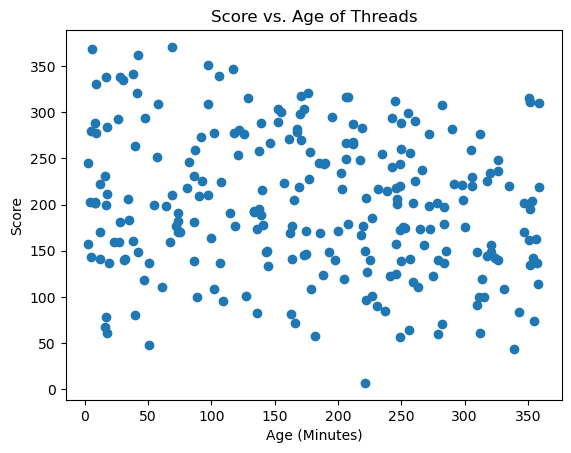

In [ ]:
#Generate a scatter plot for Score vs Age
plt.scatter(
    x = threads_df['age_minutes'],
    y = threads_df['scores']
)
plt.xlabel('Age (Minutes)')
plt.ylabel('Score')
plt.title('Score vs. Age of Threads')
plt.show()

<Axes: xlabel='thread_id', ylabel='count'>

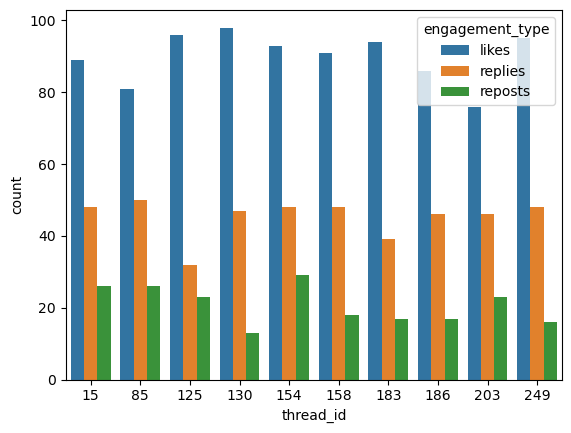

In [ ]:
#generate bar plot for top 10 threads based on engagement type
top_10_melted = pd.melt(top_10_threads,
                        id_vars=['thread_id'],
                        value_vars=['likes', 'replies','reposts'],
                        var_name='engagement_type',
                        value_name='count'
                        )
sns.barplot(data=top_10_melted, x='thread_id', y = 'count', hue='engagement_type')

# Stretch Goals

## Simulate-user posts

In [ ]:
import uuid

threads_df_multi_user = threads_df
user_ids = []
for _ in range(100):
    user_ids.append(str(uuid.uuid4())) #generate 100 users using uuids, and assign them to each post using random sampling


threads_df_multi_user['user_id'] = random.choices(user_ids, k=250)
print(threads_df_multi_user)

     thread_id  likes  replies  reposts  age_minutes      scores  \
0            1     17       46       26          134  193.278999   
1            2     83        2        5          265  173.373545   
2            3     51       49       12          138  258.499103   
3            4     53       10        8          357  137.020949   
4            5     12       42       15           75  170.072304   
..         ...    ...      ...      ...          ...         ...   
245        246     68       31       12          202  234.572613   
246        247     77        5       20           64  198.332311   
247        248     13       11       17          256   64.033778   
248        249     95       48       16           42  362.187524   
249        250     84       23       22            8  288.452884   

                                  user_id  
0    c10c665b-914c-4b3e-badb-02ca28360080  
1    7c8bd351-0435-4c36-b160-23239383bf78  
2    634f4439-5d50-4bcf-96c5-567ad1b65507  
3    4a

## Parametrize the half-life decay value

In [9]:
def calculate_scores(df, decay_constant):
    engagement_score = (df['likes'] * 2) + (df['replies'] * 3) + (df['reposts'] * 2.5)
    score = engagement_score * np.exp(-df['age_minutes'] / decay_constant)
    return score

# You can now easily change the decay rate
threads_df['score_fast_decay'] = calculate_scores(threads_df, decay_constant=60)
threads_df['score_slow_decay'] = calculate_scores(threads_df, decay_constant=240)

print(threads_df)

     thread_id  likes  replies  reposts  age_minutes      scores  \
0            1     17       46       26          134  193.278999   
1            2     83        2        5          265  173.373545   
2            3     51       49       12          138  258.499103   
3            4     53       10        8          357  137.020949   
4            5     12       42       15           75  170.072304   
..         ...    ...      ...      ...          ...         ...   
245        246     68       31       12          202  234.572613   
246        247     77        5       20           64  198.332311   
247        248     13       11       17          256   64.033778   
248        249     95       48       16           42  362.187524   
249        250     84       23       22            8  288.452884   

                                  user_id  score_fast_decay  score_slow_decay  
0    c10c665b-914c-4b3e-badb-02ca28360080         25.399432        135.602364  
1    7c8bd351-0435-4c36

## Alternative Engagement weightings

 The current weights (likes: 2, replies: 3, reposts: 2.5)